# Econ 470 HW 5.1
## Claire Hamilton

In [1]:
# Import packages

suppressPackageStartupMessages({
  library(tidyverse)
  library(stargazer)
  library(lmtest)
  library(AER)
  library(fixest)
})

In [2]:
# Import data

final_data <- read_csv("../data/output/final_exp_data.csv", show_col_types = FALSE)

In [3]:
# head(final_data)

# Summarize the Data

## Question 1

In [15]:
# Convert uncomp care to millions

final_data <- final_data %>%
  mutate(uncomp_care_mil = tot_uncomp_care_charges / 1e6)

# Table

uc_table <- final_data %>%
  filter(year >= 2010 & year <= 2018) %>%
  group_by(year) %>%
  summarize(
    mean_uncomp_care = mean(uncomp_care_mil, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(year) %>%
  mutate(mean_uncomp_care = round(mean_uncomp_care, 2)) %>%
  rename(
    Year = year,
    `Mean Uncompensated Care ($ Millions)` = mean_uncomp_care
  )

uc_table

Year,Mean Uncompensated Care ($ Millions)
<dbl>,<dbl>
2010,17.35
2011,17.84
2012,19.00
2013,19.25
2014,16.02
2015,15.70
2016,20.32
2017,23.28
2018,26.41


## Question 2

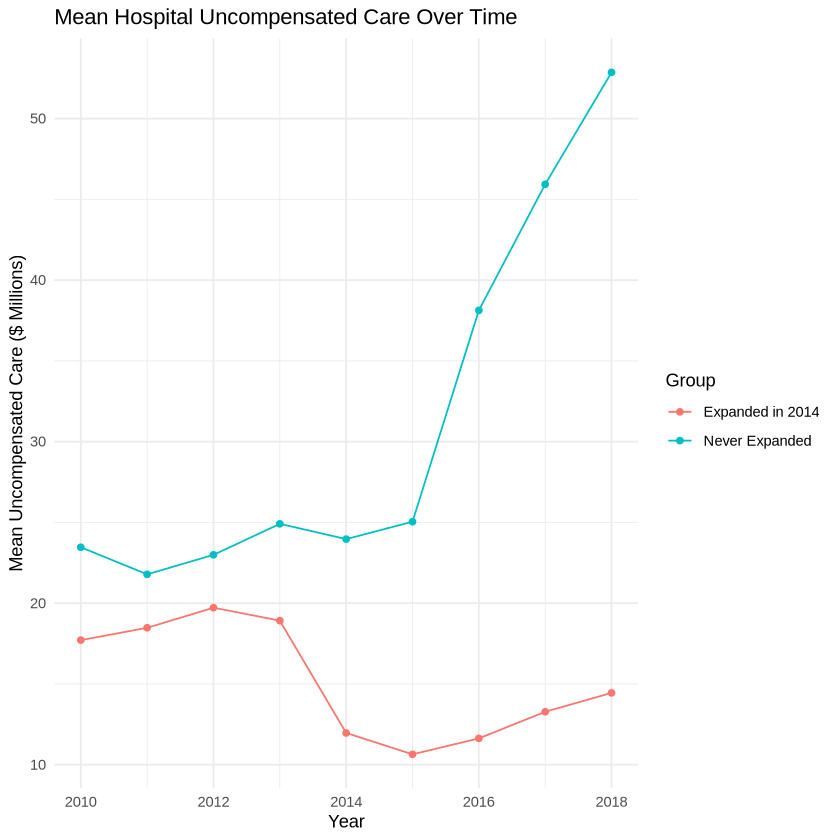

In [5]:
# Create groups

plot_data <- final_data %>%
  filter(year >= 2010 & year <= 2018) %>%
  filter(
    exp_year == 2014 | is.na(exp_year)
  ) %>%
  mutate(
    expansion_group = case_when(
      exp_year == 2014 ~ "Expanded in 2014",
      is.na(exp_year)  ~ "Never Expanded"
    ),
    uncomp_care_mil = tot_uncomp_care_charges / 1e6
  )

# Calculate mean

plot_summary <- plot_data %>%
  group_by(year, expansion_group) %>%
  summarize(
    mean_uc = mean(uncomp_care_mil, na.rm = TRUE),
    .groups = "drop"
  )

# Table

ggplot(plot_summary, aes(x = year, y = mean_uc, color = expansion_group)) +
  geom_line() +
  geom_point() +
  labs(
    x = "Year",
    y = "Mean Uncompensated Care ($ Millions)",
    color = "Group",
    title = "Mean Hospital Uncompensated Care Over Time"
  ) +
  theme_minimal()

## Question 3

In [6]:
dd_data <- final_data %>%
  filter(year %in% c(2012, 2015)) %>%
  filter(exp_year == 2014 | is.na(exp_year)) %>%
  mutate(
    group = case_when(
      exp_year == 2014 ~ "Expansion (2014)",
      is.na(exp_year)  ~ "Non-Expansion"
    ),
    uncomp_care_mil = tot_uncomp_care_charges / 1e6
  )

dd_table <- dd_data %>%
  group_by(group, year) %>%
  summarize(
    mean_uc = mean(uncomp_care_mil, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(mean_uc = round(mean_uc, 2))

dd_table2 <- dd_table %>%
  pivot_wider(
    names_from = year,
    values_from = mean_uc
  ) %>%
  rename(
    `2012 (Pre)` = `2012`,
    `2015 (Post)` = `2015`,
    `Group` = `group`
  )

dd_table2

Group,2012 (Pre),2015 (Post)
<chr>,<dbl>,<dbl>
Expansion (2014),19.72,10.64
Non-Expansion,22.99,25.04


## Question 4

My results show that states that expanded Medicaid in 2014 saw substantial declines in uncompensated care, while states that never expanded saw large increases in uncompensated care from 2014 to 2018. Medicaid expansion as part of the Affordable Care Act increased access to Medicaid, so states that expanded likely had far fewer uninsured patients. Thus, since more people were covered by Medicaid in states that expanded in 2014, these states saw declines in uncompensated care. 

# Estimate ATEs

## Question 5

In [7]:
# Filter / clean data 

reg.dat <- final_data %>%
  filter(exp_year == 2014 | is.na(exp_year)) %>%
  mutate(
    expand_ever = case_when(
      exp_year == 2014 ~ 1,
      is.na(exp_year) ~ 0
    ),
    post = ifelse(year >= 2014, 1, 0),
    treat = post * expand_ever,
    uncomp_care_m = tot_uncomp_care_charges / 1e6
  ) %>%
  filter(!is.na(uncomp_care_m))

# Regression

dd.uc.reg <- lm(uncomp_care_m ~ post + expand_ever + post * expand_ever, data = reg.dat)
summary(dd.uc.reg)


Call:
lm(formula = uncomp_care_m ~ post + expand_ever + post * expand_ever, 
    data = reg.dat)

Residuals:
    Min      1Q  Median      3Q     Max 
 -47.73  -18.87  -12.45   -2.05 2454.19 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)        23.263      1.086  21.428  < 2e-16 ***
post               17.726      1.351  13.125  < 2e-16 ***
expand_ever        -4.371      1.381  -3.166  0.00155 ** 
post:expand_ever  -23.628      1.720 -13.738  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 70.52 on 30995 degrees of freedom
Multiple R-squared:  0.02426,	Adjusted R-squared:  0.02416 
F-statistic: 256.9 on 3 and 30995 DF,  p-value: < 2.2e-16


The DD estimate of the effect of Medicaid expansion on hospital uncompensated care is around -23.6 million dollars. This indicates that, after 2014, hospitals in expansion states had a reduction in uncompensated care of about $23.6 million compared to hospitals in non-expansion states.

## Question 6

In [8]:
# Run TWFE model 

m.twfe <- feols(
  uncomp_care_m ~ treat | provider_number + year,
  data = reg.dat,
  cluster = ~ state
)

summary(m.twfe)

OLS estimation, Dep. Var.: uncomp_care_m
Observations: 30,999 
Fixed-effects: provider_number: 3,679,  year: 10
Standard-errors: Clustered (state) 
      Estimate Std. Error  t value   Pr(>|t|)    
treat -25.1495    5.83036 -4.31354 0.00011021 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 29.5     Adj. R2: 0.806195
             Within R2: 0.036102

When including hospital and year fixed effects, the estimated effect of Medicaid expansion on uncompensated care is approximately −25.1 million dollars. This is close to the estimate from Question 5 (−$23.6 million), showing the results are similar even after adjusting for differences between hospitals and changes over time. Overall, both models suggest that Medicaid expansion substantially reduced hospital uncompensated care.

## Question 7

In [9]:
reg.dat.full <- final_data %>%
  mutate(
    expand_ever = ifelse(!is.na(exp_year), 1, 0),
    post = ifelse(year >= exp_year & expand_ever == 1, 1, 0),
    treat = post,
    uncomp_care_m = tot_uncomp_care_charges / 1e6
  ) %>%
  filter(!is.na(uncomp_care_m))

m.twfe.full <- feols(
  uncomp_care_m ~ treat | provider_number + year,
  data = reg.dat.full,
  cluster = ~ state
)

summary(m.twfe.full)

OLS estimation, Dep. Var.: uncomp_care_m
Observations: 41,329 
Fixed-effects: provider_number: 4,896,  year: 10
Standard-errors: Clustered (state) 
      Estimate Std. Error  t value   Pr(>|t|)    
treat -19.7576    4.49706 -4.39344 5.5139e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 27.0     Adj. R2: 0.803666
             Within R2: 0.031865

When including all states, the estimated effect of Medicaid expansion is about −19.8 million dollars, which is smaller in magnitude but similar to the estimate from Question 6 (−25.1 million dollars). The results are different because the control group now includes states that expanded later, so those states would then look more like expansion states. This reduces the difference between the treated and control groups.

## Question 8

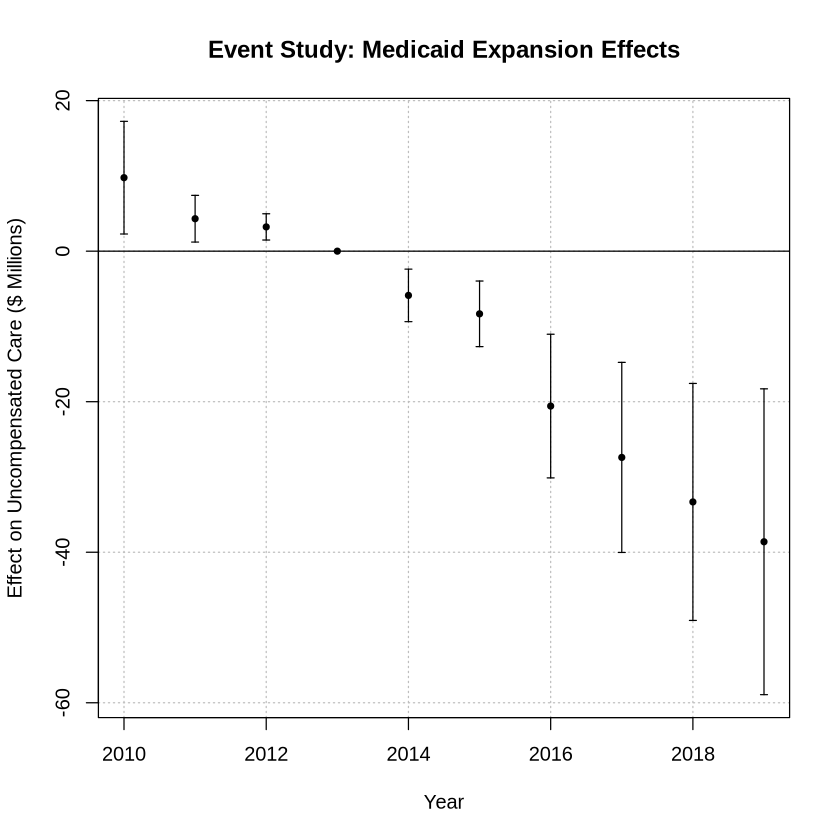

In [10]:
reg.dat <- final_data %>%
  filter(exp_year == 2014 | is.na(exp_year)) %>%
  mutate(
    expand_ever = ifelse(!is.na(exp_year) & exp_year == 2014, 1, 0),
    uncomp_care_m = tot_uncomp_care_charges / 1e6
  ) %>%
  filter(!is.na(uncomp_care_m))

mod.twfe <- feols(
  uncomp_care_m ~ i(year, expand_ever, ref = 2013) | provider_number + year,
  data = reg.dat,
  cluster = ~ state
)

iplot(mod.twfe,
      xlab = "Year",
      ylab = "Effect on Uncompensated Care ($ Millions)",
      main = "Event Study: Medicaid Expansion Effects",
      ref.line = 0)

## Question 9

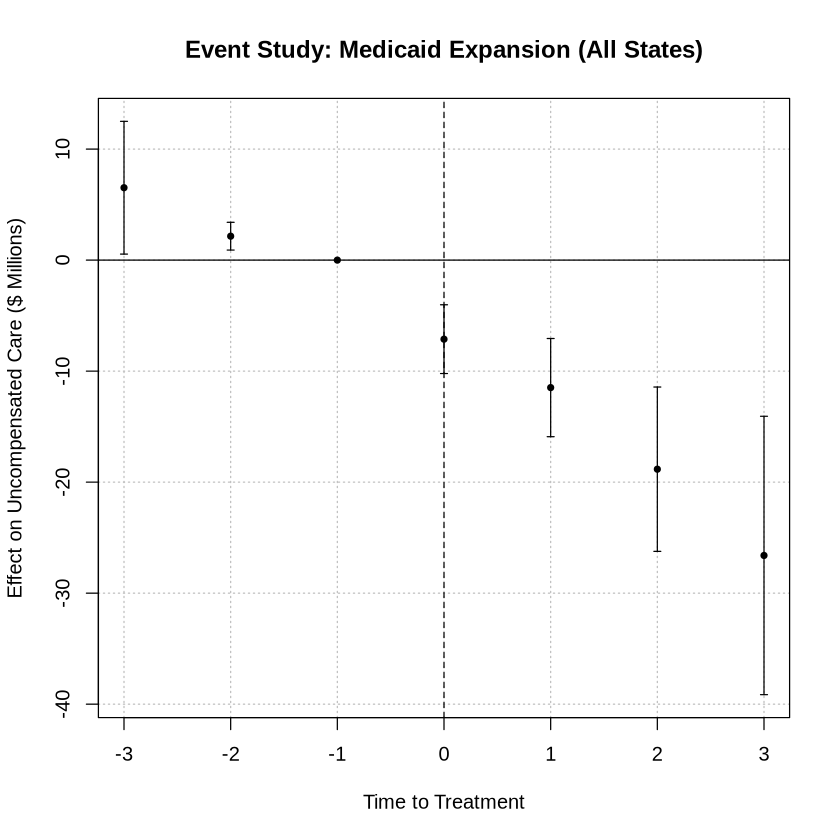

In [11]:
# Create event time variable

reg.dat.full <- final_data %>%
  filter(!is.na(medicaid_exp_status)) %>%
  mutate(
    expand_ever = ifelse(!is.na(exp_year), 1, 0),
    time_to_treat = ifelse(expand_ever == 1, year - exp_year, 0)
  )

# Bin endpoints

reg.dat.full <- reg.dat.full %>%
  mutate(
    time_to_treat = ifelse(time_to_treat <= -3, -3, time_to_treat),
    time_to_treat = ifelse(time_to_treat >= 3, 3, time_to_treat),
    uncomp_care_m = tot_uncomp_care_charges / 1e6
  ) %>%
  filter(!is.na(uncomp_care_m))

# Run and plot

mod.twfe.full <- feols(
  uncomp_care_m ~ i(time_to_treat, expand_ever, ref = -1) | provider_number + year,
  data = reg.dat.full,
  cluster = ~ state
)

iplot(mod.twfe.full,
      xlab = "Time to Treatment",
      ylab = "Effect on Uncompensated Care ($ Millions)",
      main = "Event Study: Medicaid Expansion (All States)",
      ref.line = 0)

## Question 10

Medicaid expansion is associated with a large and statistically significant reduction in hospital uncompensated care, around 20–25 million dollars per hospital. The event study shows clear declines after expansion, though the pre-treatment estimates are not exactly zero, which raises some concerns about parallel trends. A limitation of the TWFE approach is that it uses states that expand later as controls, which can affect the accuracy of the estimated effect.